# Unsupervised Structure Discovery (M4/CO4)

All learned representations and unsupervised models are fit on the training partition only. Validation and test rows may be transformed or assigned but are never used to refit the vectorizer, scaler, clusterer, anomaly detector, or reducer. References are SRC-005, SRC-006, and SRC-016–SRC-020 in `docs/sources.md`.

In [1]:
import sys
from pathlib import Path
root_dir = Path('..').resolve() if Path('../src').exists() else Path('.').resolve()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage

from src.features.text import TfidfTextPipeline
from src.features.unsupervised_features import UnsupervisedFeatureAugmenter
from src.models.unsupervised import UnsupervisedAnalyzer, reduce_for_visualization

train_path = root_dir / 'tests' / 'fixtures' / 'train.csv'
val_path = root_dir / 'tests' / 'fixtures' / 'test.csv'
train = pd.read_csv(train_path)
validation = pd.read_csv(val_path)
tfidf = TfidfTextPipeline(min_df=1, max_df=1.0, max_features=200)
X_train = tfidf.fit_transform(train['content'])
X_validation = tfidf.transform(validation['content'])
print(f'X_train shape: {X_train.shape}, X_validation shape: {X_validation.shape}')


X_train shape: (14, 164), X_validation shape: (4, 164)


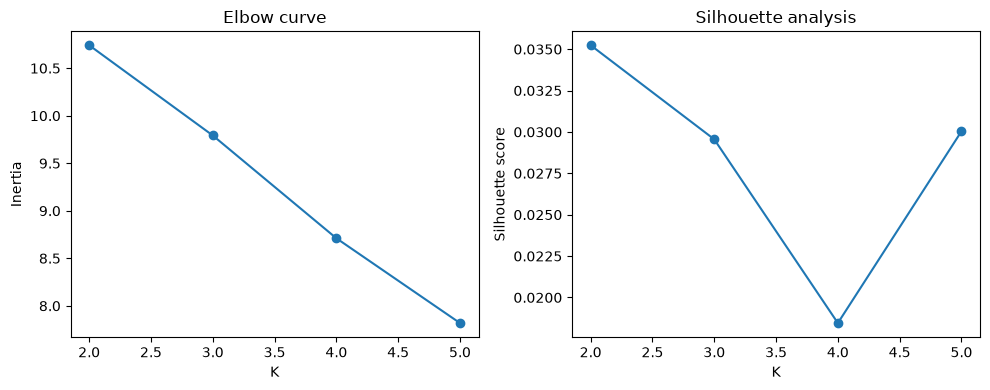

In [2]:
# Elbow/inertia and silhouette analysis on training representations only.
analyzer = UnsupervisedAnalyzer(random_state=42)
k_values = [2, 3, 4, 5]
diagnostics = analyzer.kmeans_diagnostics(X_train, k_values)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(diagnostics.k_values, diagnostics.inertias, marker='o')
axes[0].set(xlabel='K', ylabel='Inertia', title='Elbow curve')
axes[1].plot(diagnostics.k_values, diagnostics.silhouette_scores, marker='o')
axes[1].set(xlabel='K', ylabel='Silhouette score', title='Silhouette analysis')
plt.tight_layout()


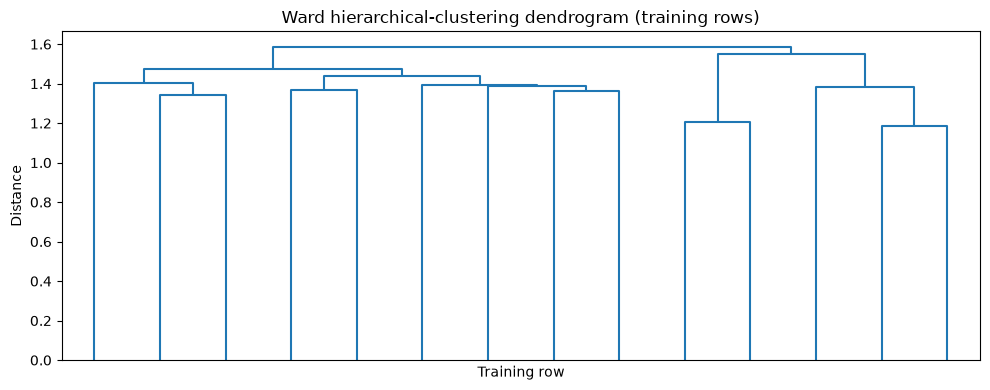

In [3]:
# Hierarchical clustering and dendrogram visualization.
dense_train = X_train.toarray()
linkage_matrix = linkage(dense_train, method='ward')
plt.figure(figsize=(10, 4))
dendrogram(linkage_matrix, no_labels=True)
plt.title('Ward hierarchical-clustering dendrogram (training rows)')
plt.xlabel('Training row')
plt.ylabel('Distance')
plt.tight_layout()


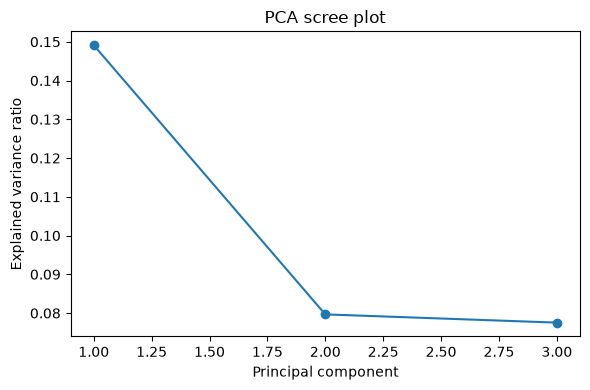

In [4]:
# Standardized PCA and scree plot.
pca_train = analyzer.fit_pca(X_train, n_components=min(3, X_train.shape[1]), standardize=True)
variance = analyzer.explained_variance_ratio_
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(variance) + 1), variance, marker='o')
plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.title('PCA scree plot')
plt.tight_layout()


UMAP optional dependency unavailable: Install umap-learn to create UMAP projections


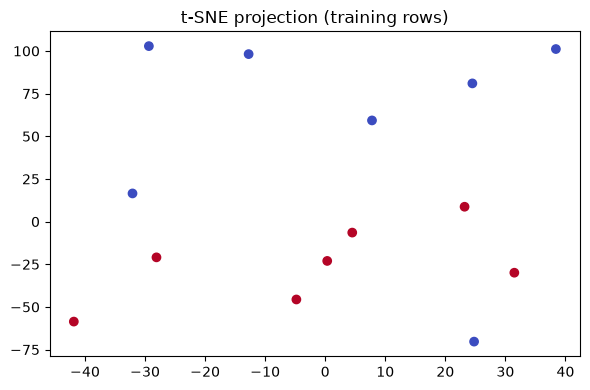

In [5]:
# Visualization-only manifold projections. These coordinates are not treated as truth-preserving features.
tsne = reduce_for_visualization(X_train, method='tsne', n_components=2, perplexity=2, random_state=42)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(tsne[:, 0], tsne[:, 1], c=train['label'], cmap='coolwarm')
ax.set_title('t-SNE projection (training rows)')
plt.tight_layout()

try:
    umap_projection = reduce_for_visualization(X_train, method='umap', n_components=2, random_state=42)
    plt.figure(figsize=(6, 4))
    plt.scatter(umap_projection[:, 0], umap_projection[:, 1], c=train['label'], cmap='coolwarm')
    plt.title('UMAP projection (training rows)')
    plt.tight_layout()
except RuntimeError as exc:
    print(f'UMAP optional dependency unavailable: {exc}')


In [6]:
# K-Means/DBSCAN/anomaly feature synthesis: fit only on X_train, transform validation separately.
augmenter = UnsupervisedFeatureAugmenter(
    n_clusters=2, dbscan_eps=0.5, dbscan_min_samples=2,
    include_minibatch_kmeans=True, include_dbscan=True, include_anomaly=True,
)
X_train_augmented = augmenter.fit_transform(X_train)
X_validation_augmented = augmenter.transform(X_validation)
print('train augmented:', X_train_augmented.shape)
print('validation augmented:', X_validation_augmented.shape)
print('feature names:', augmenter.get_feature_names_out())


train augmented: (14, 17)
validation augmented: (4, 17)
feature names: ['feature_0' 'feature_1' 'feature_2' 'feature_3' 'feature_4' 'feature_5'
 'feature_6' 'feature_7' 'feature_8' 'feature_9' 'feature_10' 'feature_11'
 'feature_12' 'kmeans_cluster_id' 'minibatch_kmeans_cluster_id'
 'dbscan_cluster_id' 'isolation_forest_anomaly_score']
